In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
def seed_everything(seed=42):
    import os
    import random
    import numpy as np
    import tensorflow as tf

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
    os.environ["TF_NUM_INTEROP_THREADS"] = "1"

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)

    tf.config.optimizer.set_jit(False)


seed_everything(42)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from math import sqrt
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import random
from dataclasses import dataclass
from typing import List, Optional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
from pathlib import Path

dataset_name = "webbrowsing_train.csv"
data_file = Path.cwd().parents[1] / "data" / "filtered" / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)

Loaded: C:\Users\EJ17UF\OneDrive - Aalborg Universitet\Desktop\ms\data\filtered\webbrowsing_train.csv


In [5]:
target = 'mac_dl_brate'
exclude = ['ue_ident']
features = [col for col in df.columns if col not in exclude]

input_steps = 96
prediction_horizon = 96

train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.1)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print('Training Data:', len(train_df))
print('Validation Data:', len(val_df))
print('Test Data:', len(test_df))


scaler_all = MinMaxScaler()

train_scaled = scaler_all.fit_transform(train_df[features])
val_scaled = scaler_all.transform(val_df[features])
test_scaled = scaler_all.transform(test_df[features])


def create_sequences_patchtst_multivariate(data, input_steps, prediction_horizon, index):
    X, y, dates = [], [], []

    for i in range(len(data) - input_steps - prediction_horizon + 1):
        X_seq = data[i:i + input_steps, :]   # (input_steps, n_channels)
        y_seq = data[i + input_steps:i + input_steps + prediction_horizon, :]  # (pred_len, n_channels)

        date_seq = index[i + input_steps:i + input_steps + prediction_horizon]

        X.append(X_seq)
        y.append(y_seq)
        dates.append(date_seq)

    return np.array(X), np.array(y), dates

X_train_patch, y_train_patch, train_dates = create_sequences_patchtst_multivariate(
    train_scaled, input_steps, prediction_horizon, train_df.index
)

X_val_patch, y_val_patch, val_dates = create_sequences_patchtst_multivariate(
    val_scaled, input_steps, prediction_horizon, val_df.index
)

X_test_patch, y_test_patch, test_dates = create_sequences_patchtst_multivariate(
    test_scaled, input_steps, prediction_horizon, test_df.index
)

print("X_train_patch shape:", X_train_patch.shape)
print("y_train_patch shape:", y_train_patch.shape)

print("X_val_patch shape:", X_val_patch.shape)
print("y_val_patch shape:", y_val_patch.shape)

print("X_test_patch shape:", X_test_patch.shape)
print("y_test_patch shape:", y_test_patch.shape)



test_index_avg = [ts[len(ts) // 2] for ts in test_dates]

Training Data: 12508
Validation Data: 1786
Test Data: 3575


X_train_patch shape: (12317, 96, 5)
y_train_patch shape: (12317, 96, 5)
X_val_patch shape: (1595, 96, 5)
y_val_patch shape: (1595, 96, 5)
X_test_patch shape: (3384, 96, 5)
y_test_patch shape: (3384, 96, 5)


In [6]:
# Feature-as-Token Embedding
class FeatureEmbedding(layers.Layer):
    """
    Input:  [B, lookback, n_features]
    Output: [B, n_features, d_model]
    """
    def __init__(self, lookback, d_model, dropout=0.1):
        super().__init__()
        self.proj = layers.Dense(d_model)
        self.dropout = layers.Dropout(dropout)
        self.lookback = lookback

    def call(self, x, training=False):
        # transpose to make features the tokens
        x = tf.transpose(x, perm=[0, 2, 1])  # [B, n_features, lookback]
        x = self.proj(x)                     # [B, n_features, d_model]
        return self.dropout(x, training=training)

# Encoder Layer (Pre-LN)
class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )

        self.ff = tf.keras.Sequential([
            layers.Dense(d_ff, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(d_model),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        # Pre-LN
        attn_out = self.attn(self.norm1(x), self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x), training=training)
        return x


# iTransformer Model
class iTransformer(Model):
    def __init__(self,
                 lookback,
                 horizon,
                 n_features,
                 d_model=64,
                 num_heads=4,
                 num_layers=2,
                 d_ff=128,
                 dropout=0.1):
        super().__init__()

        self.lookback = lookback
        self.horizon = horizon
        self.n_features = n_features

        self.embedding = FeatureEmbedding(lookback, d_model, dropout)

        self.encoder_layers = [
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ]

        self.norm = layers.LayerNormalization()

        # Per-feature forecast head
        self.projection = layers.Dense(horizon)

    def call(self, x, training=False):
        # Normalize over time
        mean = tf.reduce_mean(x, axis=1, keepdims=True)
        std = tf.math.reduce_std(x, axis=1, keepdims=True) + 1e-5
        x = (x - mean) / std

        # Feature tokens
        x = self.embedding(x, training=training)

        # Encoder
        for layer in self.encoder_layers:
            x = layer(x, training=training)

        x = self.norm(x)

        # Forecast per feature
        out = self.projection(x)              # [B, n_features, horizon]
        out = tf.transpose(out, [0, 2, 1])    # [B, horizon, n_features]

        # De-normalize
        out = out * std[:, :1, :] + mean[:, :1, :]
        return out

In [7]:

model = iTransformer(
    lookback=input_steps,
    d_model=64,
    num_heads=8,
    num_layers=3,
    d_ff=128,
    horizon=prediction_horizon,
    n_features=len(features)
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
    )

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

In [8]:
history = model.fit(
    X_train_patch,
    y_train_patch,
    validation_data=(X_val_patch, y_val_patch),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


 1/97 ━━━━━━━━━━━━━━━━━━━━ 14:46 9s/step - loss: 0.0249 - mae: 0.0905

 2/97 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0246 - mae: 0.0899 

 3/97 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0248 - mae: 0.0901

 4/97 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0248 - mae: 0.0902

...

92/97 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0149 - mae: 0.0690

93/97 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0149 - mae: 0.0690

95/97 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0149 - mae: 0.0690

96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0149 - mae: 0.0690

97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0149 - mae: 0.0690 - val_loss: 0.0133 - val_mae: 0.0671


In [9]:
y_pred_scaled = model.predict(X_test_patch)
#print("y_pred_scaled shape:", y_pred_scaled.shape)

# target channel index
target_idx = features.index(target)

# extract only the target channel from scaled data
y_test_target_scaled = y_test_patch[:, :, target_idx]      # shape: (n_samples, horizon)
y_pred_target_scaled = y_pred_scaled[:, :, target_idx]     # shape: (n_samples, horizon)

# compute metrics on scaled data
rmse_target_scaled = np.sqrt(mean_squared_error(
    y_test_target_scaled.flatten(),
    y_pred_target_scaled.flatten()
))


mae_target_scaled = mean_absolute_error(
    y_test_target_scaled.flatten(),
    y_pred_target_scaled.flatten()
)

print(f"{target} RMSE (scaled):", rmse_target_scaled)
print(f"{target} MAE (scaled):", mae_target_scaled)

  1/106 ━━━━━━━━━━━━━━━━━━━━ 43s 412ms/step

 13/106 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step   

 22/106 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 33/106 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 50/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

...

 79/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 96/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


mac_dl_brate RMSE (scaled): 0.07262027920115517
mac_dl_brate MAE (scaled): 0.046527251197043505


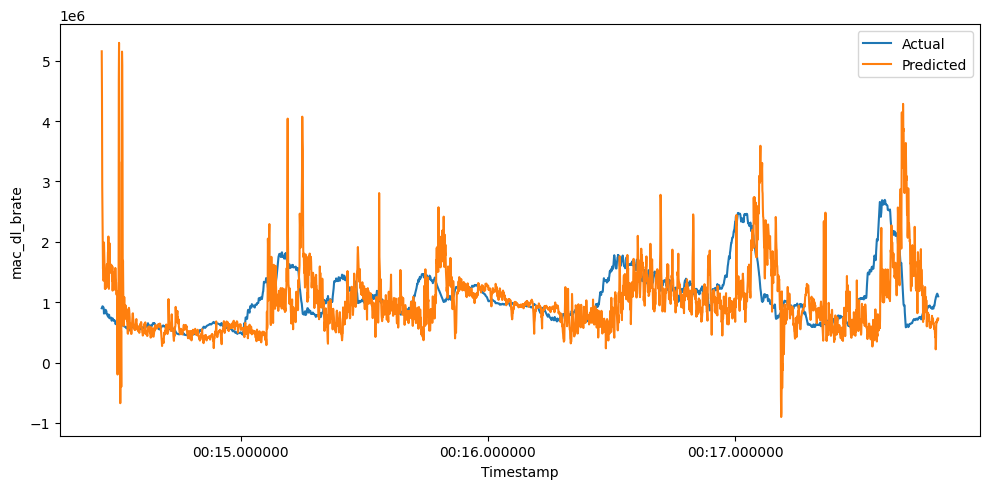

In [10]:
def inverse_transform_3d(data_3d, scaler):
    n_samples, horizon, n_channels = data_3d.shape
    data_2d = data_3d.reshape(-1, n_channels)
    data_inv = scaler.inverse_transform(data_2d)
    return data_inv.reshape(n_samples, horizon, n_channels)


# inverse transform to original scale
y_test_original = inverse_transform_3d(y_test_patch, scaler_all)
y_pred_original = inverse_transform_3d(y_pred_scaled, scaler_all)


# extract target only in original scale
y_test_target_original = y_test_original[:, :, target_idx]   # (n_samples, horizon)
y_pred_target_original = y_pred_original[:, :, target_idx]   # (n_samples, horizon)

# average across each forecast horizon
actual_window_avg = y_test_target_original.mean(axis=1)      # (n_samples,)
pred_window_avg = y_pred_target_original.mean(axis=1)        # (n_samples,)

window_time = [ts[len(ts)//2] for ts in test_dates]
window_time = pd.to_datetime(window_time)

# plot
plt.figure(figsize=(10, 5))
plt.plot(window_time, actual_window_avg, label='Actual')
plt.plot(window_time, pred_window_avg, label='Predicted')
plt.xlabel('Timestamp')
plt.ylabel(f'{target}')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
results_dir = Path("../results/metrics/web_browsing")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "iTransformer",
    "setting": "multivariate",
    "dataset": "web_browsing",
    "rmse": rmse_target_scaled,
    "mae": mae_target_scaled,
}])

metrics_file = results_dir / "itrans_multi_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\web_browsing\itrans_multi_metrics.csv
